<a href="https://colab.research.google.com/github/KULDEEPSONI-source/MACHINE-LEARNING/blob/main/visualize%20decision%20tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.dropna(how='any', inplace=True)

#fillna --> fill the missing values

In [13]:
len(df)

7032

In [14]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.Churn.value_counts()/len(df)*100

,count
Churn,
No,73.421502
Yes,26.578498


In [16]:
X=df.drop(['customerID', 'Churn'], axis=1)

In [17]:
y=df.Churn.values

In [18]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [19]:
y

array(['No', 'No', 'Yes', ..., 'No', 'Yes', 'No'], dtype=object)

In [20]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [21]:
# Convert categorical features to numericals --> Feature Encoding --> Dummy Encoding

X = pd.get_dummies(X, columns=['gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], drop_first=True)

In [22]:
X.head(1)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [23]:
# Splitting the data into training & test

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25)

In [24]:
len(X_train)


5274

In [25]:
len(X_test)

1758

In [26]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [27]:
X_train_sc

array([[-0.43463655, -0.14048336,  0.81549767, ..., -0.52982902,
         1.39867009, -0.54067579],
       [-0.43463655, -1.24011781, -0.31906947, ...,  1.88740132,
        -0.71496488, -0.54067579],
       [ 2.30077293,  0.87769668,  0.84373726, ..., -0.52982902,
         1.39867009, -0.54067579],
       ...,
       [ 2.30077293,  1.3664231 ,  1.37198375, ...,  1.88740132,
        -0.71496488, -0.54067579],
       [-0.43463655,  0.02242544, -0.33235869, ..., -0.52982902,
        -0.71496488, -0.54067579],
       [-0.43463655,  0.83696948,  0.98991868, ...,  1.88740132,
        -0.71496488, -0.54067579]])

In [28]:
X_test_sc

array([[-0.43463655,  0.87769668,  0.50818446, ..., -0.52982902,
        -0.71496488, -0.54067579],
       [ 2.30077293,  1.12205989,  1.3703226 , ..., -0.52982902,
         1.39867009, -0.54067579],
       [-0.43463655, -0.79211859, -1.47689274, ..., -0.52982902,
        -0.71496488,  1.84953722],
       ...,
       [ 2.30077293, -1.28084501, -0.6463165 , ..., -0.52982902,
         1.39867009, -0.54067579],
       [-0.43463655,  0.38897026,  1.14108356, ..., -0.52982902,
         1.39867009, -0.54067579],
       [-0.43463655, -0.83284579, -0.62306037, ..., -0.52982902,
        -0.71496488, -0.54067579]])

In [29]:
# Call the DT Classifier
from sklearn.tree import DecisionTreeClassifier

# Initiating the classifier
model_dt = DecisionTreeClassifier(max_depth=2)

# Passing the data to classifier
model_dt.fit(X_train_sc, y_train)

DecisionTreeClassifier(max_depth=2)

In [30]:
y_pred_dt = model_dt.predict(X_test_sc)

In [31]:
# Classification metrics = to check how the model is behaving

from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred_dt)*100)

78.38452787258248


This code snippet uses **scikit-learn** and **matplotlib** to visualize a Decision Tree model that you have already trained.

Here is the breakdown of what each line does:

### 1. The Imports

```python
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

```

* **plot_tree**: This is a specialized function provided by scikit-learn designed specifically to draw the structure of a decision tree.
* **matplotlib.pyplot**: This is the standard library used for plotting in Python. It provides the "canvas" (figure) upon which the tree will be drawn.

---

### 2. Setting Up the Canvas

```python
plt.figure(figsize=(10,8))

```

* This creates a new figure (a blank window) with a specific size: **10 inches wide by 8 inches tall**.
* If your tree is very deep or complex, you might need to increase these numbers (e.g., (20, 15)) to keep the text from overlapping or becoming too small to read.

---

### 3. Plotting the Tree

```python
plot_tree(model_dt, filled=True, feature_names=X_train.columns, class_names=True)

```

This is the core function call. Here is what the arguments do:

* **model_dt**: This is your trained Decision Tree model object (e.g., a DecisionTreeClassifier).
* **filled=True**: This adds color to the nodes. The colors indicate the majority class (for classification) or the value (for regression). It makes the tree much easier to interpret at a glance.
* **feature_names=X_train.columns**: Instead of showing indices like X[0] <= 0.5, this uses the actual names of your columns (e.g., Age <= 30), which makes the tree readable.
* **class_names=True**: This displays the target class names in each node (e.g., "Yes" or "No"), showing you which group is currently favored at that point in the tree.

---

### 4. Displaying the Result

```python
plt.show()

```

* This command tells Matplotlib to render the image you just constructed. Without this, the plot would remain in memory but would not appear on your screen.

---

### How to interpret the resulting plot:

When you look at the generated tree, you will see:

* **Decision Nodes (Rectangles):** These show the feature and the threshold used to split the data.
* **Gini/Entropy:** You will see a value representing the "impurity" of that node. A value of 0 means the node is "pure" (all samples belong to one class).
* **Samples:** How many data points reached that specific node.
* **Value:** How many samples of each class are in that node.
* **Leaves (Bottom Nodes):** These represent the final decision or prediction made by the model.



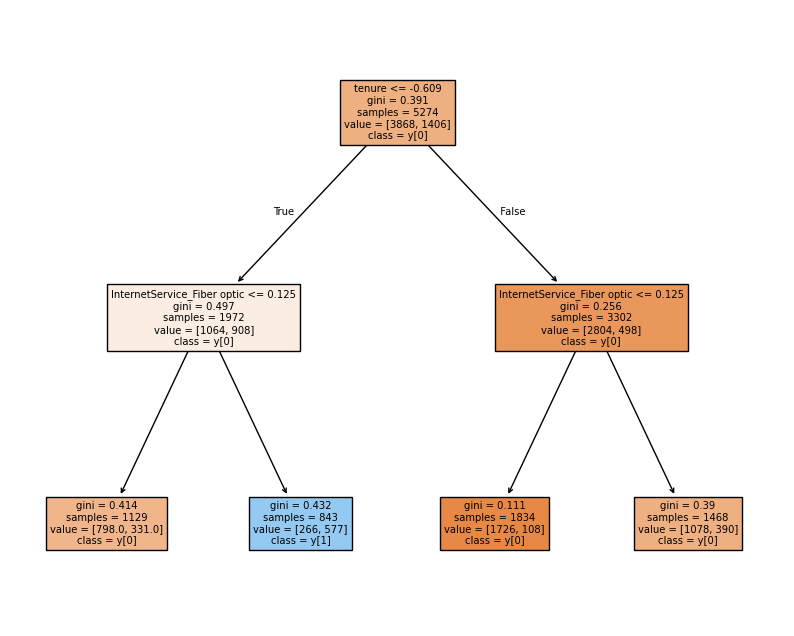

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_tree(model_dt, filled=True, feature_names =X_train.columns, class_names=True)
plt.show()

#graphviz
#dtreeviz

This code provides an alternative, often superior, way to visualize your decision tree compared to the plot_tree method. Instead of using Matplotlib, it uses **Graphviz**, an open-source graph visualization software.

Graphviz is generally preferred for trees because it handles complex, deep layouts much better and produces high-quality, professional-looking images.

### Breakdown of the Code

#### 1. Exporting to a DOT file

```python
export_graphviz(model_dt, out_file="tree.dot", feature_names=X_train.columns,
                class_names=True, filled=True, proportion=True,
                special_characters=True)

```

* **export_graphviz**: This function converts your trained model into **DOT language**, which is a plain-text format used to describe graphs.
* **out_file="tree.dot"**: Saves the graph description to a file named tree.dot in your working directory.
* **proportion=True**: This is a great addition. Instead of showing the raw count of samples (e.g., "150 samples"), it shows them as percentages (e.g., "0.5" for 50%), which is often more helpful for understanding class distribution.
* **special_characters=True**: Ensures that if your feature names contain special symbols, they will be rendered correctly in the final image.

#### 2. Reading and Rendering the Graph

```python
with open("tree.dot") as f:
    dot_graph = f.read()
graph = graphviz.Source(dot_graph, format='png')
graph

```

* **with open(...) as f**: This reads the contents of the file you just created into a variable.
* **graphviz.Source(...)**: This creates a Python object representing the graph.
* **format='png'**: Specifies that you want to render the graph as a PNG image.
* **graph (the final line)**: By simply calling the variable graph in a Jupyter Notebook or similar environment, it automatically triggers the rendering and displays the visual tree below the cell.

---

### Key Advantages of this Method

* **Professional Layout**: Graphviz automatically calculates the best spacing, preventing the "squished" look that often happens with plt.plot_tree when a tree has many nodes.
* **File Persistence**: You now have a physical tree.dot file on your computer. You can open this file in any text editor to see the underlying logic or use a [Graphviz online viewer](https://dreampuf.github.io/GraphvizOnline/) to view it without running Python code.
* **High Resolution**: Because it generates an external image file (PNG, PDF, etc.), the output is usually much crisper and easier to zoom in on compared to a Matplotlib plot.

### Important Note on Dependencies

For this code to work, you must have two things:

1. **The Python library**: Installed via pip install graphviz.
2. **The System Software**: You must have the [Graphviz binaries](https://graphviz.org/download/) installed on your operating system and added to your system's PATH. If you get a FileNotFoundError (specifically ExecutableNotFound), it means your computer has the Python library but cannot find the underlying Graphviz engine to perform the drawing.


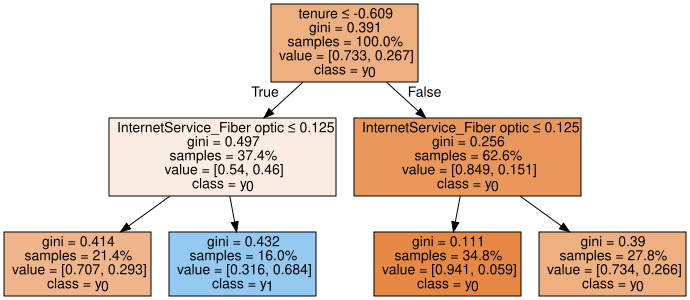

In [33]:
from sklearn.tree import export_graphviz
import graphviz

export_graphviz(model_dt, out_file="tree.dot", feature_names=X_train.columns, class_names=True, filled=True, proportion=True, special_characters=True)

with open("tree.dot") as f:
  dot_graph = f.read()
graph = graphviz.Source(dot_graph, format='png')
graph